# Application to Mixtures

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pandas import read_csv
from scipy.interpolate import interp1d
import sys
sys.path.append('/mnt/home/john8248/')

from CorrelatedConfigurations.md_init.configuration_generator import SubCellConfigurationGenerator, SubCell, PeriodicConfigurationGenerator,PeriodicConfigurationGenerator_MS, random_reject
from CorrelatedConfigurations.md_init.constants import *
from CorrelatedConfigurations.md_init.utils import rs_from_n, n_from_rs, Kappa
from CorrelatedConfigurations.md_init.ionization import Zbar_func
from CorrelatedConfigurations.md_init.g_of_r import MultiSpeciesGofrCalculator
from CorrelatedConfigurations.md_init.iet import Integral_Equation_Solver as IET

plt.rcParams.update({'font.size': 10})
plt.rcParams["figure.figsize"] = (5,3.5)
plt.rcParams["figure.dpi"] = 150
plt.rcParams['xtick.labelsize']=12
plt.rcParams['ytick.labelsize']=12
plt.rcParams['ytick.major.size']=5
plt.rcParams['ytick.minor.size']=3
plt.rcParams['xtick.major.size']=5
plt.rcParams['xtick.minor.size']=3
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['text.usetex'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4

### Define Mixture version of YOCP
We use Thomas-Fermi More fit with a uniform free electron density assumption to find multi-species version.

We define the Yukawa plasma based on
$$ 
\beta u_{ij}(r) = \frac{\bar{Z}_i \bar{Z}_j}{r} e^{-r/\lambda}
$$
Where $\lambda$ is the screening length, and $\bar{Z}_i$ is the mean ionization state for species $i$.
We now define 
$$ 
\tilde{r} = r/\bar{r}_I\\
n_{\rm tot} = \left(\frac{4}{3} \pi \bar{r}_I^3 \right)^{-1}
$$
for total density $n_{\rm tot} = \sum_i n_i $ over all ion species. Thus, $\bar{r}_I$ is the mean ion-sphere radius and will be the characteristic distance we use in our HNC code.
$$ 
\beta u_{ij}(\tilde{r}) = \frac{\Gamma_{ij}}{\tilde{r}} e^{-\kappa \tilde{r}},
$$
which is written in terms of 
$$
\Gamma_{ij} = \beta \frac{\bar{Z}_i \bar{Z}_j}{\bar{r}_I}\\
\kappa = \bar{r}_I / \lambda 
$$


In [5]:
# Define fundamental plasma/mixture parameters
# Use DOI: 10.1103/PhysRevE.90.033110 as example, C-H mixture ratios
T_K = 20*1e3
Te_eV = T_K * K_to_eV
names = ['H', 'C']
species_Zs = np.array([1,6]) # nuclear charge not zbar
species_mis_AU = np.array([1.00784, 12.011]) * amu_to_AU
composition = np.array([0.576, 0.424])
rho_total_gpercc = 2.94
model_type='OCP'

# Define fundamental plasma/mixture parameters
n_tot_invcc = rho_total_gpercc / (np.sum(species_mis_AU*composition) * AU_to_g)
n_tot_AU = n_tot_invcc*invcc_to_AU
species_densities_invcc = composition * n_tot_invcc

# Solve for mean ionization for each species
Zbars = Zbar_func(species_Zs, species_densities_invcc, Te_eV)
Zbar_tot = np.sum(species_densities_invcc * Zbars)/n_tot_invcc
print(f"Zbars: {Zbars}, and total Zbar={Zbar_tot:0.3f}")

# Compute characteristic ion-sphere radius
rbar_I_cm = rs_from_n(n_tot_invcc)
rbar_I_AU = rs_from_n(n_tot_AU)

# Inverse temperature
Te_AU = Te_eV * eV_to_AU 
β_AU = 1/Te_AU

# Generate coupling matrix and screening parameter for generating Yukawa potentials
Γ_matrix = Zbars[:,None]*Zbars[None,:] * β_AU/rbar_I_AU
name_matrix = np.array([[name_1+name_2 for name_1 in names] for name_2 in names])
if model_type=='OCP':
    κ = 0#Kappa(T_AU, n_AU, Zbar)
elif model_type=='YOCP':
    κ = Kappa(T_AU, n_AU, Zbar)
print(f"Modelled as Yukawa plasma:\n {name_matrix} with: \nΓ_ij\n={Γ_matrix},\n and κ={κ:0.3f}")

Zbars: [0.69508409 2.31898315], and total Zbar=1.384
Modelled as Yukawa plasma:
 [['HH' 'CH']
 ['HC' 'CC']] with: 
Γ_ij
=[[ 4.41377916 14.72552686]
 [14.72552686 49.12822631]],
 and κ=0.000


#### Run HNC code to generate pair correlations $g_{ij}$

In [8]:
N_species = len(Zbars)
ni_in_rs_array = species_densities_invcc*rbar_I_cm**3 # turns densities into units of rbar_I
bridge = None #'yukawa'
iet = IET(N_species, Γ_matrix, ni_in_rs_array, dst_type=3, h_max=1e3, oz_method='standard',
        kappa = κ, kappa_multiscale = 1.0,  R_max=20.0, N_bins=2048, closure='hnc', bridge=bridge)

iet.HNC_solve(num_iterations=10000, tol=1e-3, iters_to_wait=300,iters_to_use=5, alpha_Picard=0.4, verbose=True)
r_AU_data = iet.r_array*rbar_I_AU
gofr_data = iet.h_r_matrix[0,0]+1
gofr_func = interp1d(r_AU_data, gofr_data, bounds_error=False, fill_value=(0,1))

0: Initial condition Total Error: 6.387e-01
1: Change in c_r: 2.555e-01, HNC Error: 2.449e-02, Total Error: 6.012e-01
2: Change in c_r: 2.405e-01, HNC Error: 2.103e-02, Total Error: 5.707e-01
3: Change in c_r: 2.283e-01, HNC Error: 1.982e-02, Total Error: 5.462e-01
4: Change in c_r: 2.185e-01, HNC Error: 1.950e-02, Total Error: 5.263e-01
5: Change in c_r: 2.105e-01, HNC Error: 1.959e-02, Total Error: 5.099e-01
6: Change in c_r: 2.040e-01, HNC Error: 1.980e-02, Total Error: 4.959e-01
7: Change in c_r: 1.984e-01, HNC Error: 1.992e-02, Total Error: 4.833e-01
8: Change in c_r: 1.933e-01, HNC Error: 1.997e-02, Total Error: 4.713e-01
9: Change in c_r: 1.885e-01, HNC Error: 1.990e-02, Total Error: 4.595e-01
10: Change in c_r: 1.838e-01, HNC Error: 1.970e-02, Total Error: 4.475e-01
11: Change in c_r: 1.790e-01, HNC Error: 1.944e-02, Total Error: 4.355e-01
12: Change in c_r: 1.742e-01, HNC Error: 1.912e-02, Total Error: 4.232e-01
13: Change in c_r: 1.693e-01, HNC Error: 1.876e-02, Total Error: 

110: Change in c_r: 8.231e-02, HNC Error: 5.734e-03, Total Error: 2.027e-01
111: Change in c_r: 8.107e-02, HNC Error: 5.666e-03, Total Error: 1.996e-01
112: Change in c_r: 7.985e-02, HNC Error: 5.585e-03, Total Error: 1.966e-01
113: Change in c_r: 7.864e-02, HNC Error: 5.508e-03, Total Error: 1.936e-01
114: Change in c_r: 7.745e-02, HNC Error: 5.439e-03, Total Error: 1.907e-01
115: Change in c_r: 7.628e-02, HNC Error: 5.376e-03, Total Error: 1.878e-01
116: Change in c_r: 7.513e-02, HNC Error: 5.300e-03, Total Error: 1.850e-01
117: Change in c_r: 7.399e-02, HNC Error: 5.228e-03, Total Error: 1.822e-01
118: Change in c_r: 7.286e-02, HNC Error: 5.162e-03, Total Error: 1.794e-01
119: Change in c_r: 7.175e-02, HNC Error: 5.101e-03, Total Error: 1.766e-01
120: Change in c_r: 7.066e-02, HNC Error: 5.035e-03, Total Error: 1.740e-01
121: Change in c_r: 6.958e-02, HNC Error: 4.966e-03, Total Error: 1.713e-01
122: Change in c_r: 6.852e-02, HNC Error: 4.902e-03, Total Error: 1.687e-01
123: Change 

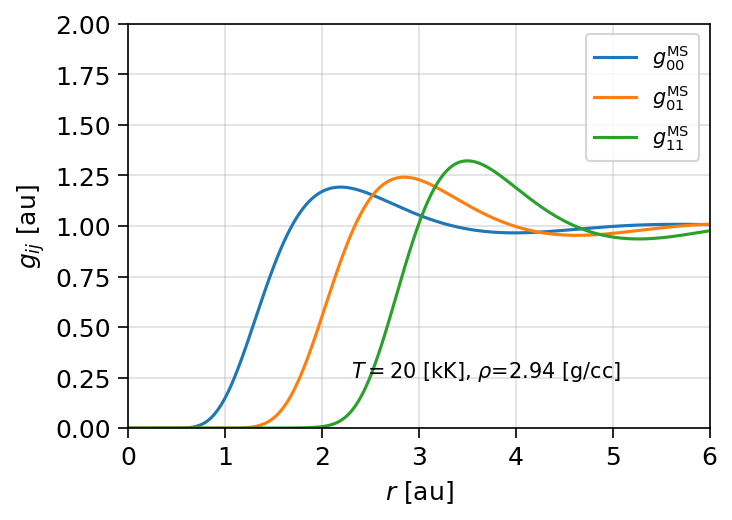

In [10]:
# iet.plot_g_all_species()
fig, ax = plt.subplots()

for i in range(N_species):
    for j in range(i,N_species):
        ax.plot(iet.r_array*rbar_I_AU, iet.h_r_matrix[i,j] + 1, label=fr"$g^{{\rm MS}}_{{ {i}{j}}}$ " )
        
ax.set_xlim(0,6)
ax.set_ylim(0,2)
ax.set_xlabel(r"$r$ [au]")
ax.set_ylabel(r"$g_{ij}$ [au]")
ax.text(2.3,0.25,fr"$T=${T_K/1e3:0.0f} [kK], $\rho$={rho_total_gpercc:0.2f} [g/cc]")
ax.legend()

# Generate the Initial MD Configuration 

In [11]:
def make_N_array(N_total, n_species):
    """
    Rounds to nearest number of each species. Corrects to N_total by adjusting most common species.
    """
    n_tot = np.sum(n_species)
    N_list = np.zeros(len(n_species))
    N_exact =  N_total*species_densities_invcc/n_tot_invcc
    dominant_species = np.argmax(n_species)
    N_approx_list = np.round(N_total * n_species/n_tot)
    N_approx_list[dominant_species] = N_total - (np.sum(N_approx_list)-N_approx_list[dominant_species])
    return N_approx_list.astype(int)

N_subcell_particles = 100
N_subcell_particles_list = make_N_array(N_subcell_particles, species_densities_invcc)
N_subcells = 1
N = N_subcell_particles*N_subcells**3
print(f"{N_subcell_particles} particles per subcell, {N} total:")
print(f"For composition {names} = {species_densities_invcc/n_tot_invcc} ")
print(f"We round {species_densities_invcc/n_tot_invcc*N_subcell_particles} to {N_subcell_particles_list} particles total ") 

L_AU = (N/n_tot_AU)**(1/3.)

100 particles per subcell, 100 total:
For composition ['H', 'C'] = [0.576 0.424] 
We round [57.6 42.4] to [58 42] particles total 


### Create g(r) with copy+paste periodic $\mathcal{O}(N^0)$ method
Create first with a method that gives a unique position to every particle across a single subcell. It then copies this across every subcell and perturbs it.


In [12]:
r_AU_data = iet.r_array*rbar_I_AU
gofr_func_matrix = np.array([[ interp1d(r_AU_data, iet.h_r_matrix[i,j]+1, bounds_error=False, fill_value=(0,1)) for i in range(N_species) ] for j in range(N_species)])

In [13]:
%%time
cfg_gen = PeriodicConfigurationGenerator_MS(L_AU, gofr_func_matrix, N_subcell_particles_list, N_subcells, min_distance_δ=0)
cfg_gen.fill_cell_with_particles()

Creating 2 species; subcell length 12.931283692677797. Total particles/subcell: 100
CPU times: user 843 ms, sys: 315 ms, total: 1.16 s
Wall time: 1.16 s


### Create g(r) with random reject for comparison
Create first with a method that gives a unique position to every particle across a single subcell. It then copies this across every subcell and perturbs it.

In [17]:
rr_positions = random_reject(N, L_AU, 0.5*rbar_I_AU)
rr_species_nums = cfg_gen.ion_species.copy() # Doesn't matter how, just an easy way to ensure total n for each species is the same

## Check g(r) against input

 N_cells = 1


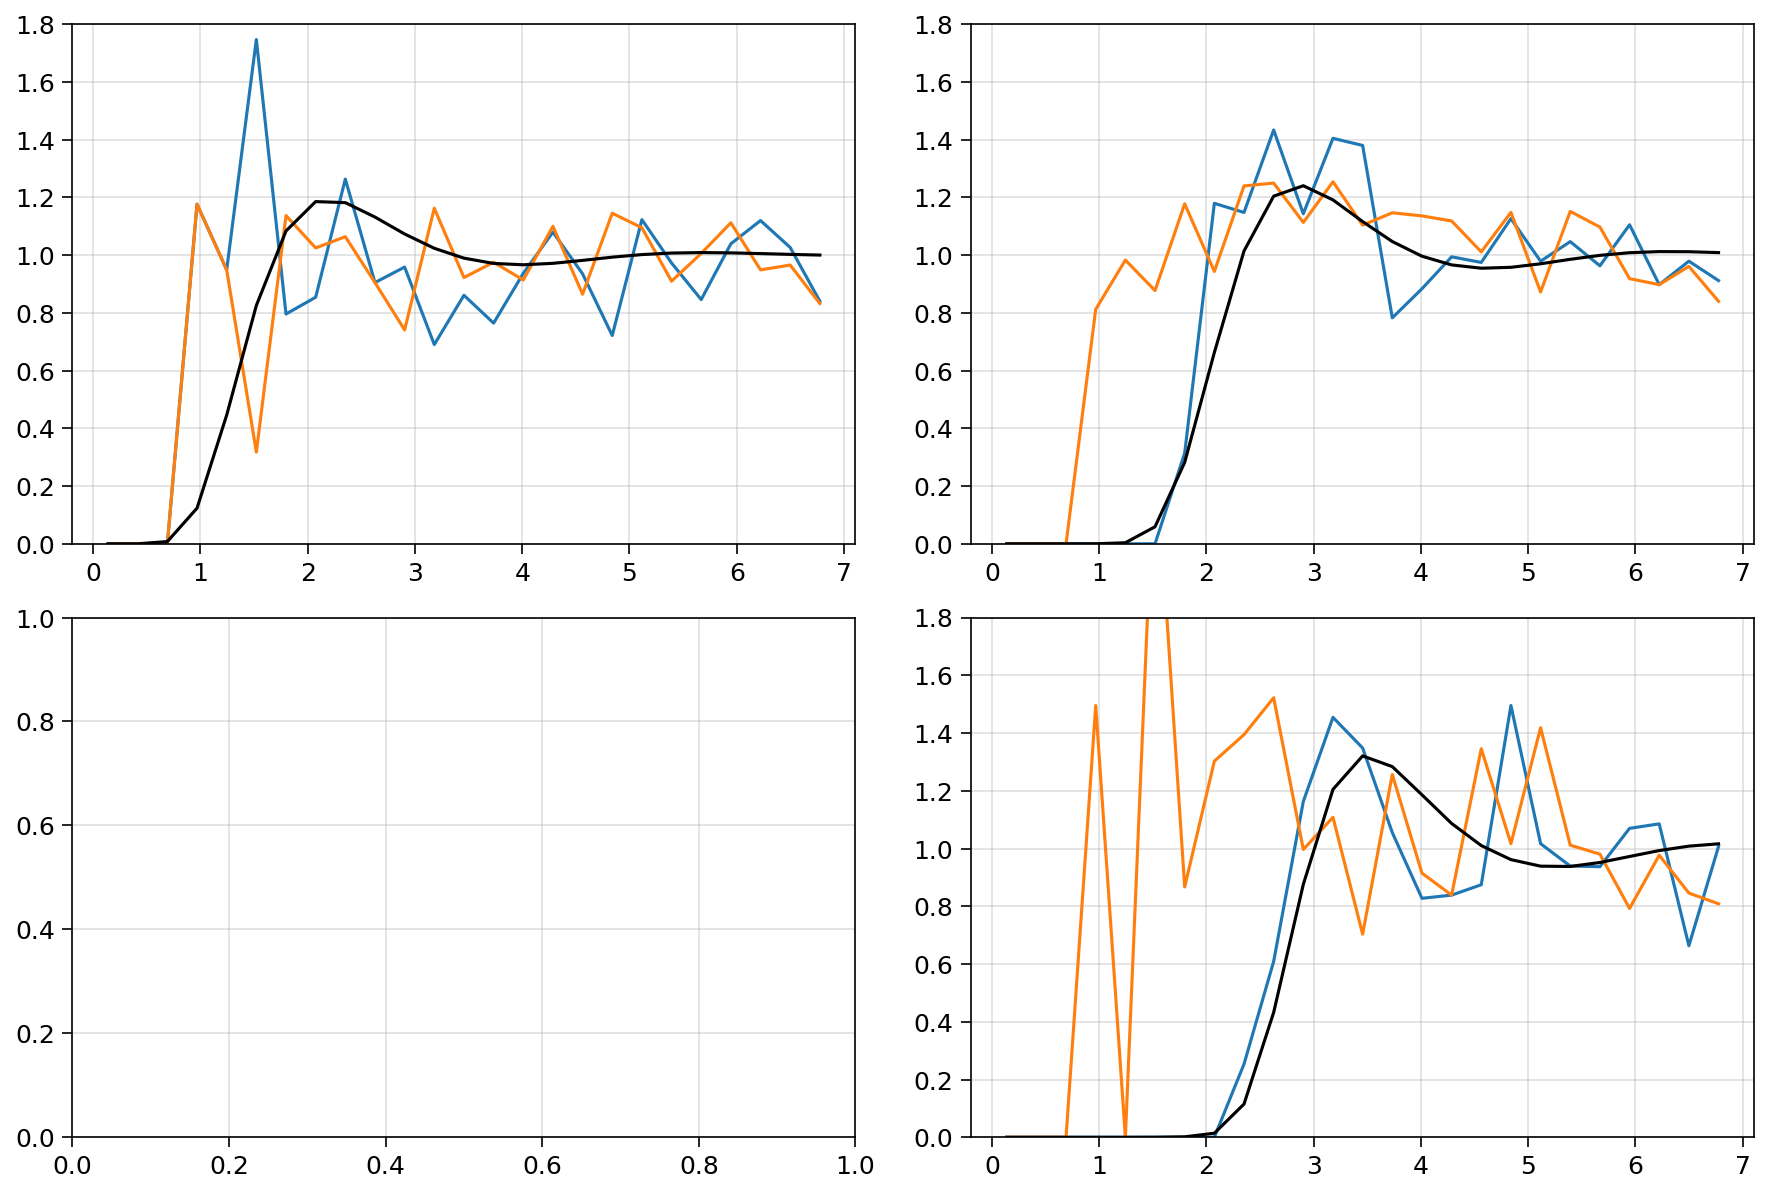

In [18]:
# Generate random particle positions in a box of length L
# Periodic
gr_calc = MultiSpeciesGofrCalculator(cfg_gen.ion_species, cfg_gen.ion_positions, L_AU, 4*rbar_I_AU , cfg_gen.dx)
r_vals, g_r_periodic = gr_calc.compute()
print(f" N_cells = {gr_calc.n_cells}")
# Subcell
# gr_calc = MultiSpeciesGofrCalculator(cell.ion_positions, L_AU, L_AU/2, cfg_gen.dx)
# r_vals, g_r_subcell = gr_calc.compute()
# random reject
gr_calc = MultiSpeciesGofrCalculator(cfg_gen.ion_species, rr_positions, L_AU, 4*rbar_I_AU , cfg_gen.dx)
r_vals, g_r_rr = gr_calc.compute()

# For example, plot g(r) (requires matplotlib)
fig, axs = plt.subplots(N_species, N_species, figsize=(12,8))
for i in range(N_species):
    for j in range(i, N_species):
        axs[i,j].plot(r_vals, g_r_periodic[i,j], '-', label="Periodic")
        axs[i,j].plot(r_vals, g_r_rr[i,j], '-', label="Random Reject")
        axs[i,j].plot(r_vals, gofr_func_matrix[i,j](r_vals), 'k', label="Input" )
        axs[i,j].set_ylim(0,1.8)
#         axs[i,j].text('yo',)
# ax.set_xlabel("r")
# ax.set_ylabel("g(r)")
# ax.legend()
plt.tight_layout()

#### Example how to save data

In [31]:
np.array([ np.concatenate([[names[species_num]],atom])  for species_num, atom in zip(cfg_gen.ion_species, cfg_gen.ion_positions)])

array([['C', '5.832552246329653', '6.506104075155234',
        '6.970052025667031'],
       ['H', '6.758274716289333', '1.8632245135716374',
        '5.804441545164213'],
       ['H', '3.4008494597408077', '3.329911805102654',
        '2.464465572950968'],
       ['C', '12.575544273655575', '1.3280913185923617',
        '1.2174413450130421'],
       ['H', '1.2997602644813873', '11.386411347385554',
        '0.2911653788725158'],
       ['H', '11.460543290057323', '9.607395711059327',
        '7.194115063079956'],
       ['H', '0.21077533517890945', '7.731918129889655',
        '8.944885696952026'],
       ['C', '11.49998117581918', '3.9136909695277677',
        '10.543066758732655'],
       ['C', '7.731918129889655', '8.341026547288974',
        '1.69181704581739'],
       ['H', '9.854233390985875', '1.6113027538014846',
        '11.986102847954303'],
       ['H', '10.625912620637054', '0.9851614206664565',
        '0.42293169489785665'],
       ['C', '10.845106924082307', '8.221570716

In [30]:
np.sort(np.array([ np.concatenate([[names[species_num]],atom])  for species_num, atom in zip(cfg_gen.ion_species, cfg_gen.ion_positions)]), axis=0) # Need sort so species together

array([['C', '0.21077533517890945', '0.0', '0.0'],
       ['C', '0.27122302825711353', '0.0', '0.0'],
       ['C', '0.42293169489785665', '0.0', '0.16399876695714577'],
       ['C', '0.43809799159283674', '0.0', '0.2134732183440234'],
       ['C', '0.5057228447194876', '0.145356346508128',
        '0.2911653788725158'],
       ['C', '0.7990643480828009', '0.2107884516868876',
        '0.3855566440865413'],
       ['C', '0.9851614206664565', '0.4405921520468155',
        '0.42293169489785665'],
       ['C', '1.056938677042785', '0.7513051999585063',
        '0.5300750402950267'],
       ['C', '1.2997602644813873', '0.7729655382768947',
        '0.5989531729525999'],
       ['C', '1.3246634555332741', '0.9851614206664565',
        '0.75439926124939'],
       ['C', '1.593662960988433', '1.3158929634406853',
        '0.792243907760221'],
       ['C', '1.6135032202071296', '1.3280913185923617',
        '0.8363746979260301'],
       ['C', '1.6290140694194255', '1.5953567845667571',
        '

In [34]:
import os

folder_path = "../data/"

# Check if the folder exists
if not os.path.exists(folder_path):
    # Create the folder
    os.makedirs(folder_path)
    print(f"Folder '{folder_path}' created successfully.")
else:
    print(f"Folder '{folder_path}' already exists.")

# mcpdf method
# mcpdf_data = np.sort(np.array([ np.concatenate([[names[species_num]],atom])  for species_num, atom in zip(cfg_gen.ion_species, cfg_gen.ion_positions)]), axis=0) # Need sort so species together
mcpdf_data = np.array([ np.concatenate([[names[species_num]],atom])  for species_num, atom in zip(cfg_gen.ion_species, cfg_gen.ion_positions)])
mcpdf_save_name = "_".join([f"{name}{xi}" for name, xi in zip(names, composition)]) + f"_{rho_total_gpercc}gpercc_{Te_eV:0.3f}eV_positions_au_mcpdf_{model_type}.txt"
mcpdf_save_file = os.path.join(folder_path, mcpdf_save_name)
np.savetxt(mcpdf_save_file, mcpdf_data, fmt="%s %s %s %s")
    
# RR
# rr_data = np.sort(np.array([ np.concatenate([[names[species_num]] ,atom])  for species_num, atom in zip(rr_species_nums, rr_positions)]), axis=0) # Need sort so species together
rr_data = np.array([ np.concatenate([[names[species_num]] ,atom])  for species_num, atom in zip(rr_species_nums, rr_positions)])
rr_save_name = "_".join([f"{name}{xi}" for name, xi in zip(names, composition)]) + f"_{rho_total_gpercc}gpercc_{Te_eV:0.3f}eV_positions_au_rand_rej.txt"
rr_save_file = os.path.join(folder_path, rr_save_name)
np.savetxt(rr_save_file, rr_data, fmt="%s %s %s %s")

Folder '../data/' already exists.


#### Simulation information

In [29]:
print(f"T_K = {T_K} K")
print(f"T_Ry = {T_K*K_to_AU*2} K")
print(f"L = {L_AU:0.4f} [a.u.]")
ωp_AU = np.sqrt(np.sum(4*π*Zbars**2*species_densities_invcc*invcc_to_AU/species_mis_AU)) # Collective mode
τp_AU = 2*π/ωp_AU
dt_2AU = τp_AU/50/2 # 2 to turn into Rydberg vs Hartree units
N_NVT = 100*τp_AU/(2*dt_2AU)
print(f"For timestep dt={dt_2AU:0.4f} [2 a.u.], we run for N_NVT = {N_NVT:0.4f} steps wherein one plasma period occurs in {τp_AU/(2*dt_2AU):0.4f} steps.")

T_K = 20000.0 K
T_Ry = 0.12667239849439882 K
L = 12.9313 [a.u.]
For timestep dt=5.1552 [2 a.u.], we run for N_NVT = 5000.0000 steps wherein one plasma period occurs in 50.0000 steps.
